## General Summary Statistics

### Understanding Data Structure

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_parquet("CustomerData.parquet")
df.head()

,Customer ID,Dollars Spent 2021,Dollars Spent 2022
0,9c7cdc4c-18fd-47ba-a304-a69fd69e4326,45.636204,69.364189
1,9e30f633-4dc3-4200-831c-a5dacc53ed13,40.311935,65.053696
2,342178ad-b68d-410d-a840-2d73624f9ba2,29.037670,61.948933
3,8f4657d9-a63a-4dfa-b429-d31cb3633d79,97.266983,112.984993
4,c18da3ee-7005-49da-abf0-8070170f3dc8,44.905178,51.551075


In [ ]:
df.describe()

,Dollars Spent 2021,Dollars Spent 2022
count,20000.000000,20000.000000
mean,49.988892,64.828575
std,30.112270,34.024055
min,20.000851,4.977531
25%,28.627721,41.494162
50%,40.724171,56.444206
75%,61.652571,79.098406
max,312.478394,350.753540


In [ ]:

ID_Null_Count = df['Customer ID'].isnull().sum()
Dollars_2021_Null_Count = df['Dollars Spent 2021'].isnull().sum()
Dollars_2022_Null_Count = df['Dollars Spent 2022'].isnull().sum()

print("ID Null Count:", ID_Null_Count)
print("Dollars Spent 2021 Null Count:", Dollars_2021_Null_Count)
print("Dollars Spent 2022 Null Count:", Dollars_2022_Null_Count)

ID Null Count: 0
Dollars Spent 2021 Null Count: 0
Dollars Spent 2022 Null Count: 0


### Scatter Plots

Text(0.5, 1.0, 'Scatter Plot Between 2021 Spending and 2022 Spending')

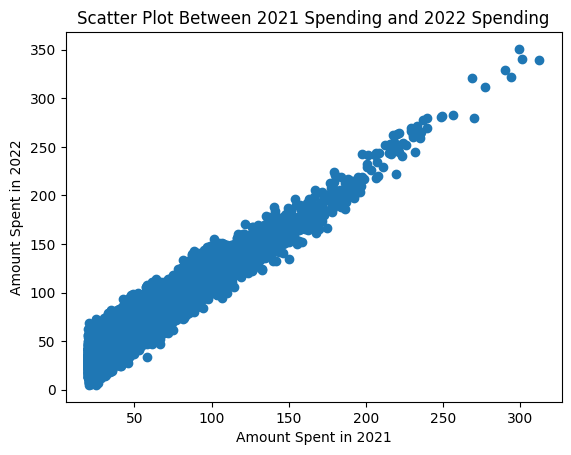

In [ ]:
plt.scatter(x=df['Dollars Spent 2021'], y=df['Dollars Spent 2022'])
plt.xlabel('Amount Spent in 2021')
plt.ylabel('Amount Spent in 2022')
plt.title('Scatter Plot Between 2021 Spending and 2022 Spending')

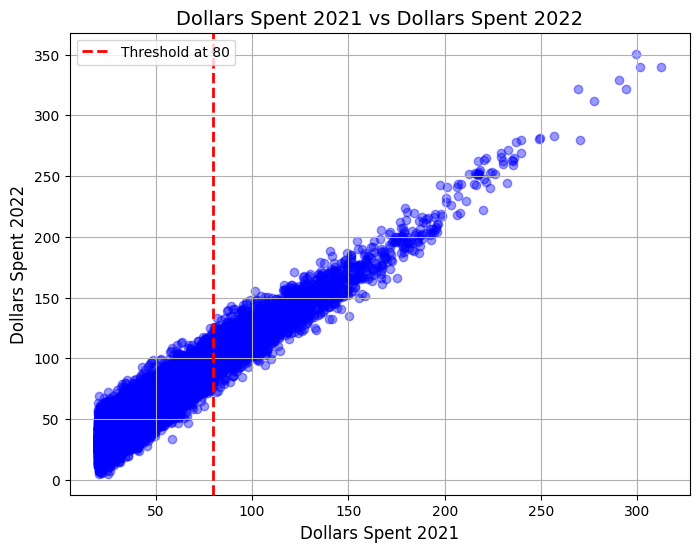

In [ ]:
x = df['Dollars Spent 2021']
y = df['Dollars Spent 2022']

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', alpha=0.4)
plt.axvline(x=80, color='red', linestyle='--', linewidth=2, label='Threshold at 80')

plt.title('Dollars Spent 2021 vs Dollars Spent 2022', fontsize=14)
plt.xlabel('Dollars Spent 2021', fontsize=12)
plt.ylabel('Dollars Spent 2022', fontsize=12)

plt.grid(True)
plt.legend(loc='upper left')
plt.show()

### Histograms

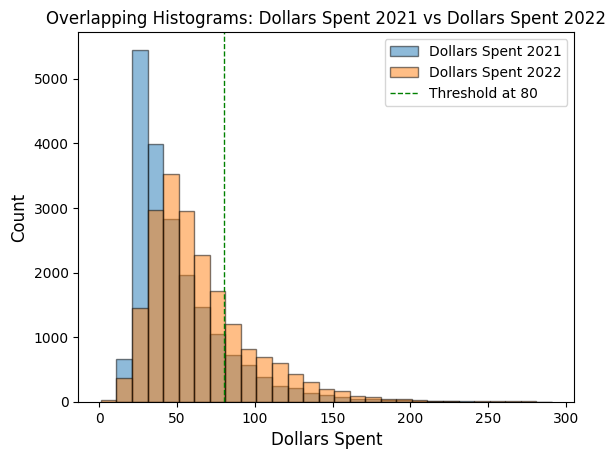

In [ ]:
plt.hist(x, bins=range(1,300,10),
         alpha=0.5, edgecolor='black',
         label='Dollars Spent 2021')

plt.hist(y, bins=range(1,300,10),
         alpha=0.5, edgecolor='black',
         label='Dollars Spent 2022')
plt.axvline(x=80, color='g', linestyle='--', linewidth=1, label='Threshold at 80')
plt.xlabel('Dollars Spent', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper right')
plt.title('Overlapping Histograms: Dollars Spent 2021 vs Dollars Spent 2022')
plt.show()

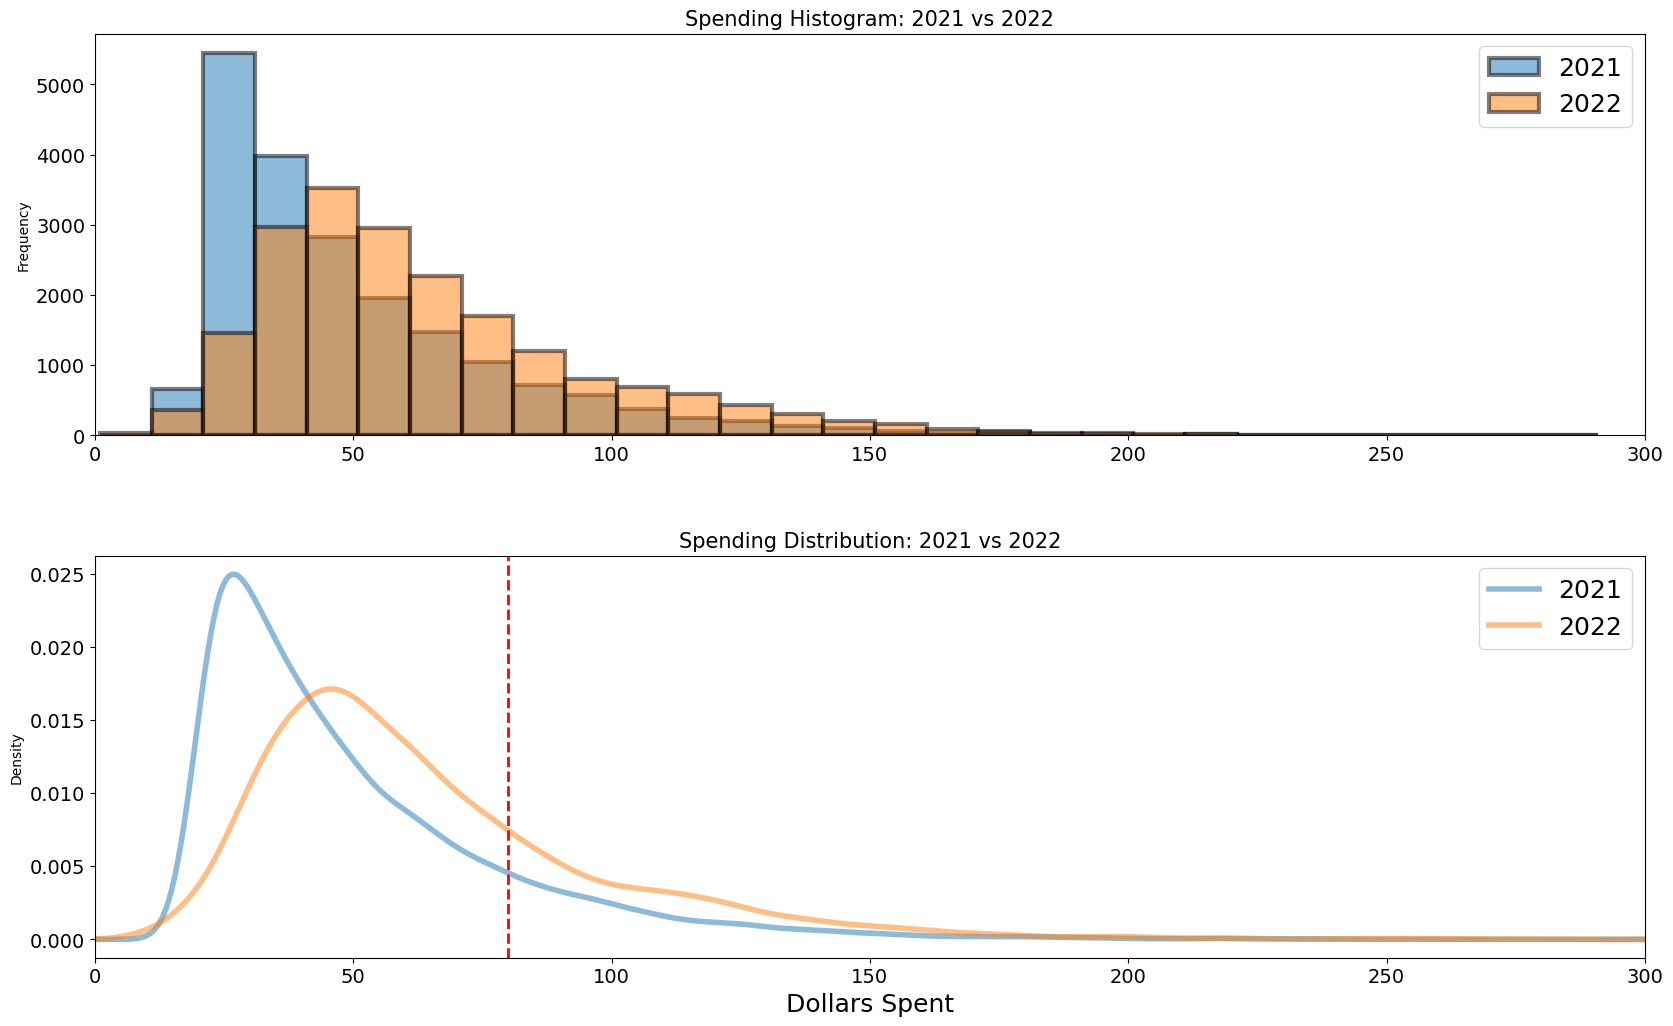

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(20, 12))
ax = axes.ravel()
ax[0].set_xlim([0,300])
ax[1].set_xlim([0,300])

df['Dollars Spent 2021'].plot(kind='hist', ax=ax[0], alpha=0.5, bins=range(1,300,10),
                              label='2021', edgecolor='black', linewidth=3)
df['Dollars Spent 2022'].plot(kind='hist', ax=ax[0], alpha=0.5, bins=range(1,300,10),
                              label='2022', edgecolor='black', linewidth=3)

ax[0].set_title('Spending Histogram: 2021 vs 2022', fontsize=15)
ax[0].legend(fontsize=18)
ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[0].tick_params(axis='both', which='minor', labelsize=14)

df['Dollars Spent 2021'].plot(kind='density', ax=ax[1], alpha=0.5, label='2021', linewidth=4)
df['Dollars Spent 2022'].plot(kind='density', ax=ax[1], alpha=0.5, label='2022', linewidth=4)

ax[1].set_title('Spending Distribution: 2021 vs 2022', fontsize=15)
ax[1].set_xlabel('Dollars Spent', fontsize=18)
ax[1].legend(fontsize=18)
plt.axvline(x=80, color='red', linestyle='--', linewidth=2, label='Threshold at 80')
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='minor', labelsize=14)

plt.subplots_adjust(hspace=0.3)

plt.show()

---


## Bandwidth Analysis

In [ ]:
x = df['Dollars Spent 2021']
y = df['Dollars Spent 2022']

In [ ]:
def plot_smoothed_effect(df, column_2021, column_2022, bin_size, zoom_range=None):
    plt.figure(figsize=(15, 10))
    bins = np.arange(df[column_2021].min(), df[column_2021].max() + bin_size, bin_size)
    binned_data = pd.cut(df[column_2021], bins=bins)
    binned_means = df.groupby(binned_data)[column_2022].mean()
    plt.plot(binned_means.index.categories.mid, binned_means.values,
                 marker='o', label=f'Bin size {bin_size}')
    plt.axvline(x=80, color='red', linestyle='--', linewidth=2, label='Threshold at 80')
    if zoom_range:
        plt.xlim(zoom_range)
    plt.title('Smoothed Spending in 2022 Based on Bins of 2021 Spending', fontsize=16)
    plt.xlabel('Dollars Spent 2021 (binned)', fontsize=14)
    plt.ylabel('Average Dollars Spent 2022', fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.show()

<ipython-input-20-3abc46a66436>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_means = df.groupby(binned_data)[column_2022].mean()


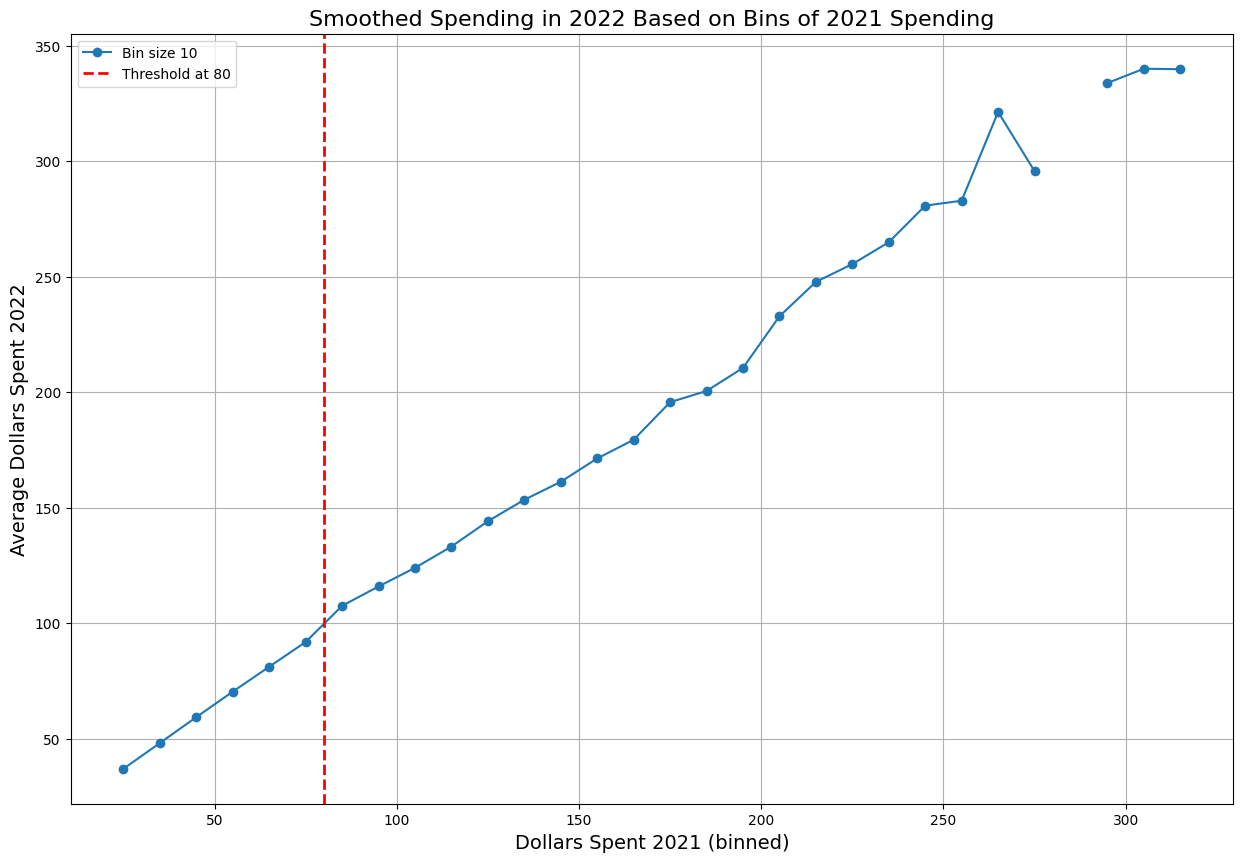

In [ ]:
plot_smoothed_effect(df, 'Dollars Spent 2021', 'Dollars Spent 2022', 10)

<ipython-input-20-3abc46a66436>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_means = df.groupby(binned_data)[column_2022].mean()


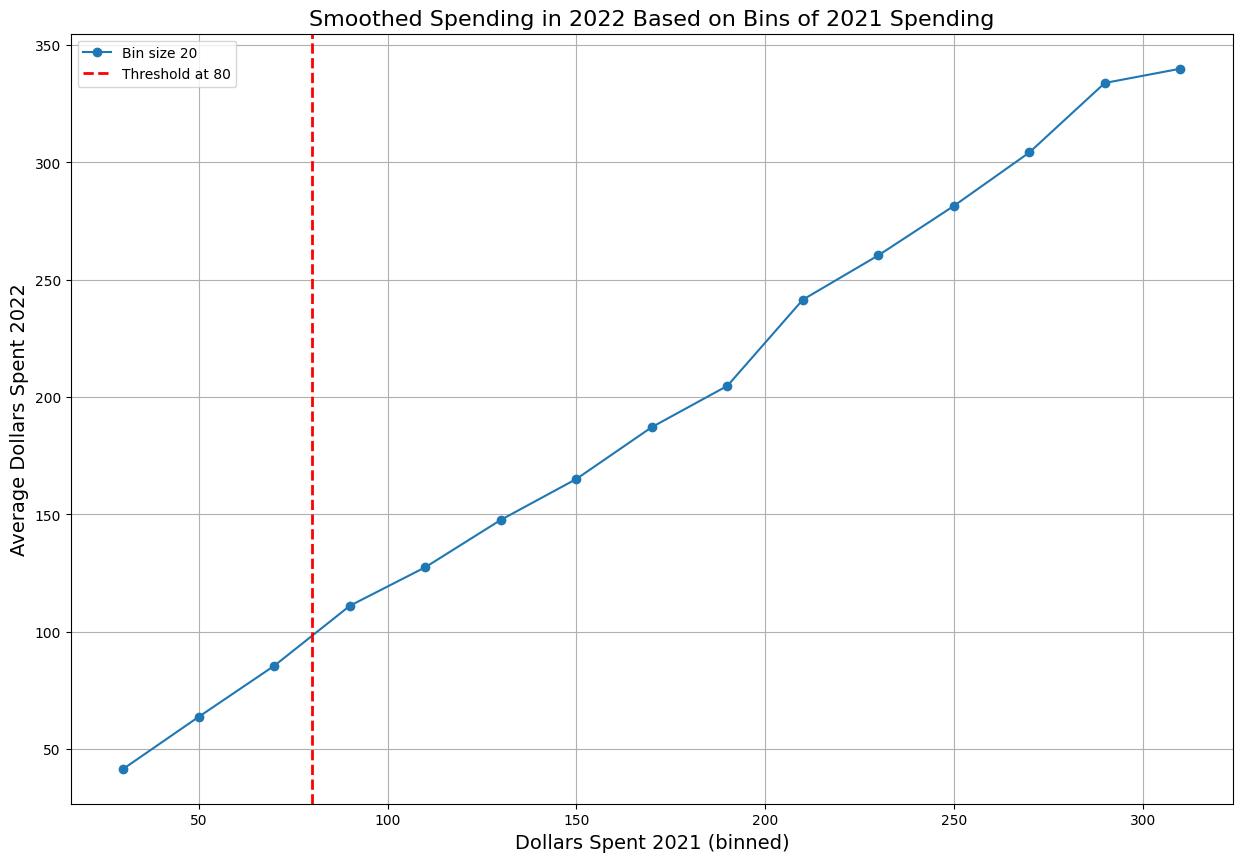

In [ ]:
plot_smoothed_effect(df, 'Dollars Spent 2021', 'Dollars Spent 2022', 20)

<ipython-input-20-3abc46a66436>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_means = df.groupby(binned_data)[column_2022].mean()


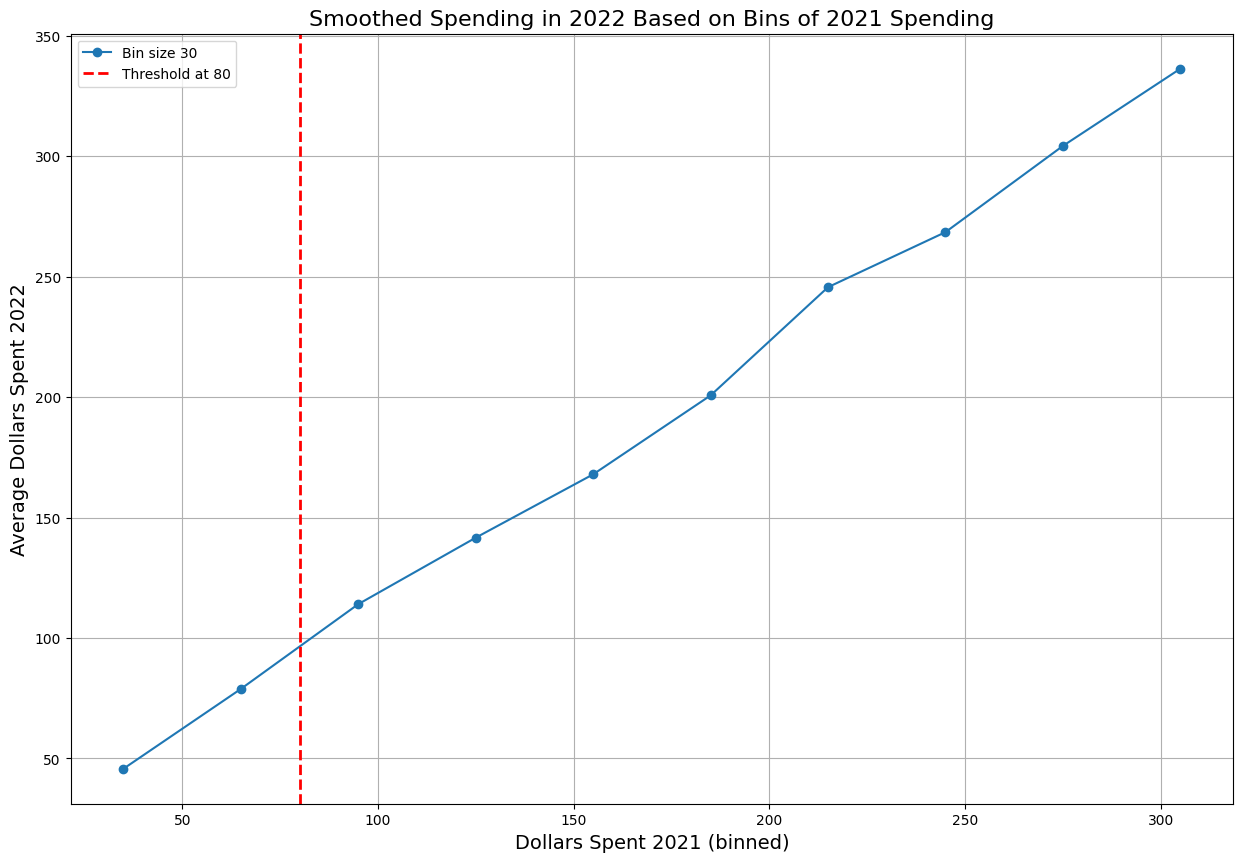

In [ ]:
plot_smoothed_effect(df, 'Dollars Spent 2021', 'Dollars Spent 2022', 30)

Observing 'jump effect' near threshold

<ipython-input-20-3abc46a66436>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_means = df.groupby(binned_data)[column_2022].mean()


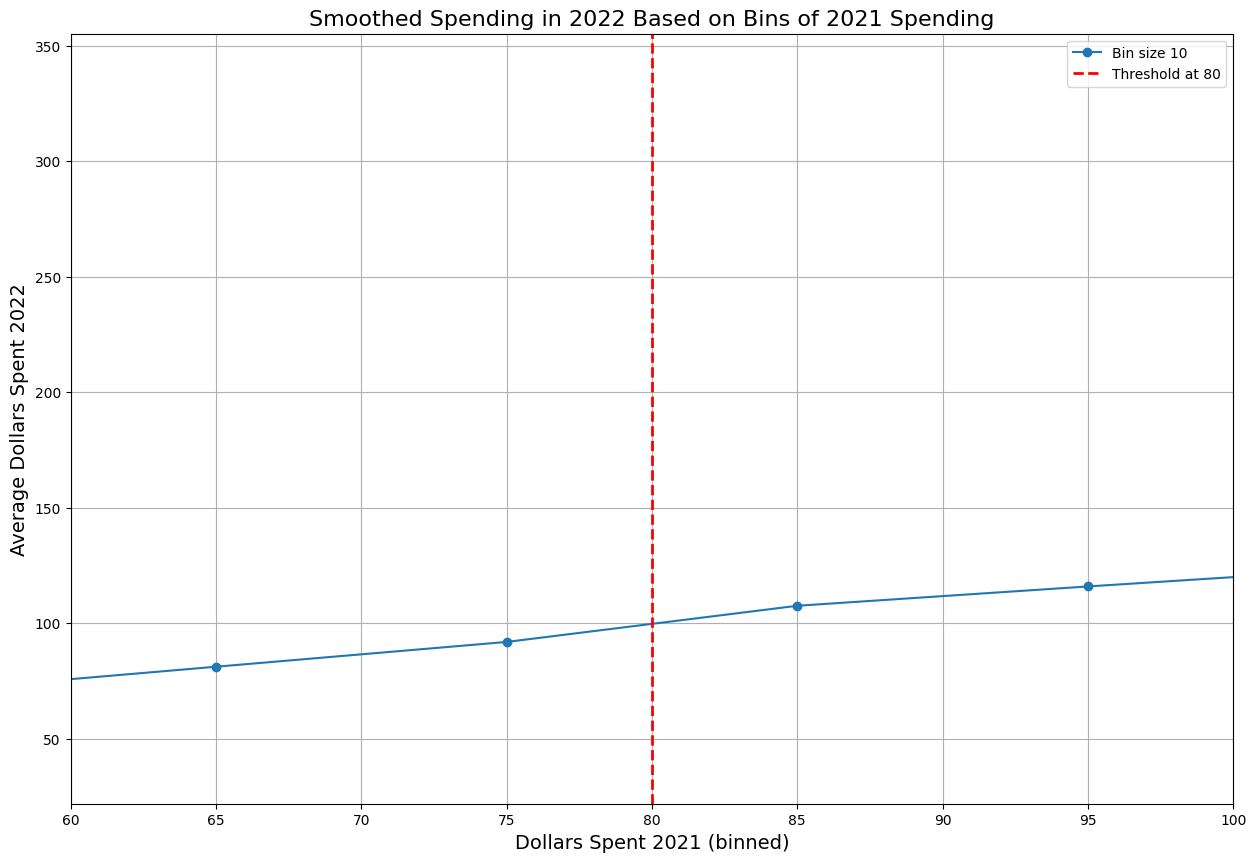

In [ ]:
plot_smoothed_effect(df, 'Dollars Spent 2021', 'Dollars Spent 2022', 10, zoom_range=(60, 100))

<ipython-input-20-3abc46a66436>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_means = df.groupby(binned_data)[column_2022].mean()


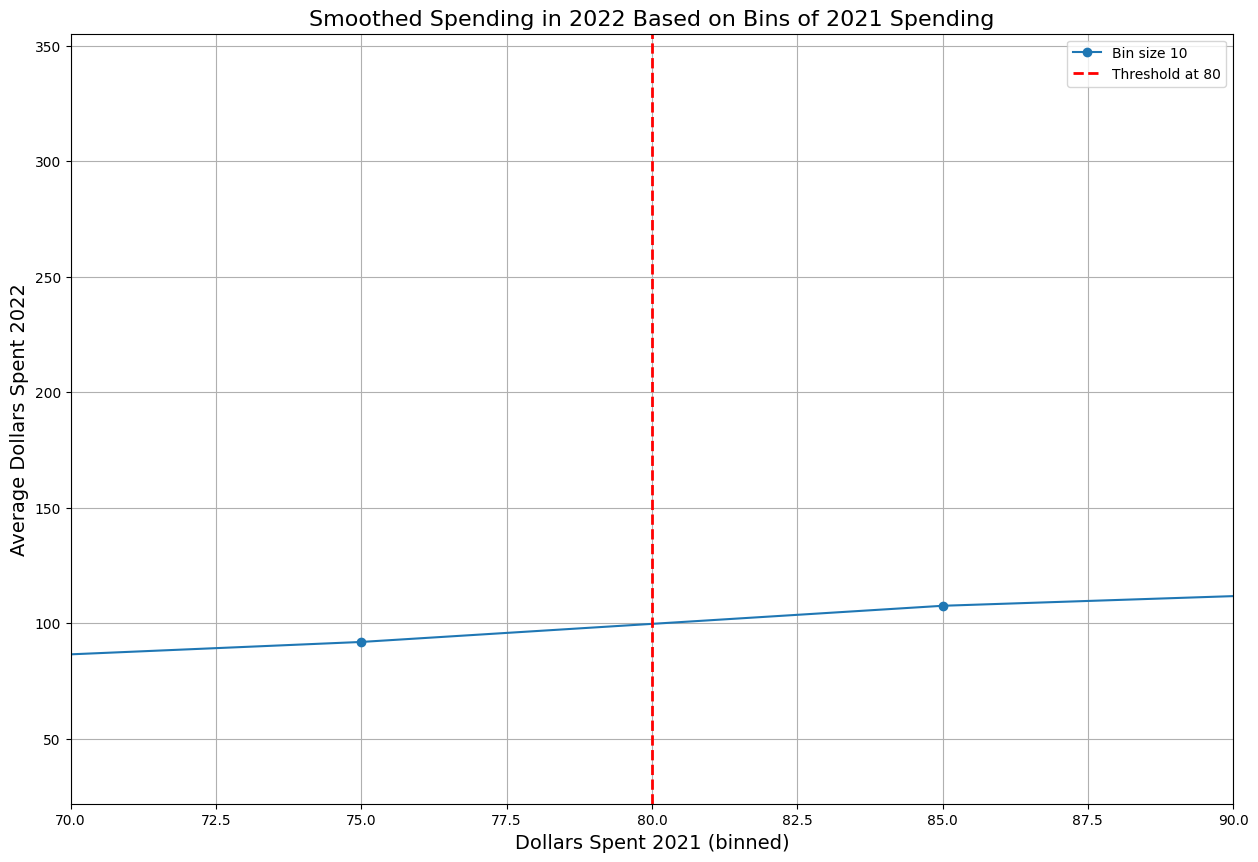

In [ ]:
plot_smoothed_effect(df, 'Dollars Spent 2021', 'Dollars Spent 2022', 10, zoom_range=(70, 90))

Explore groups of customers (data points) around region of interest (threshold neighborhood)

In [ ]:
def explore_customers_around_threshold(df, column_2021, column_2022, threshold, range_size):
    lower_bound = threshold - range_size
    upper_bound = threshold + range_size

    mask = df.index.isin(df[(df[column_2021] > lower_bound) & (df[column_2021] <= upper_bound)].index)
    customers_in_region = df.loc[mask,:]
    customers_out_region = df.loc[~mask,:]

    print("Customers in the threshold neighborhood:")
    print(customers_in_region.describe())
    print("\nCustomers outside the threshold neighborhood:")
    print(customers_out_region.describe())

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.hist(customers_in_region[column_2021], bins=range(1,300,10),
             alpha=0.5, label=f'In region ({int(lower_bound)}-{int(upper_bound)}]',
             color='blue', edgecolor='black')
    plt.hist(customers_out_region[column_2021], bins=range(1,300,10),
             alpha=0.5, label='Outside region', color='orange', edgecolor='black')
    plt.axvline(x=threshold, color='g', linestyle='--', label='Threshold at 80')
    plt.xlabel('Dollars Spent 2021')
    plt.ylabel('Number of Customers')
    plt.title('Distribution of Spending in 2021')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.hist(customers_in_region[column_2022], bins=range(1,300,10),
             alpha=0.5, label=f'In region ({int(lower_bound)}-{int(upper_bound)}]',
             color='blue', edgecolor='black')
    plt.hist(customers_out_region[column_2022], bins=range(1,300,10),
             alpha=0.5, label='Outside region', color='orange', edgecolor='black')
    plt.axvline(x=threshold, color='g', linestyle='--', label='Threshold at 80')
    plt.xlabel('Dollars Spent 2022')
    plt.ylabel('Number of Customers')
    plt.title('Distribution of Spending in 2022')
    plt.legend()

    plt.tight_layout()
    plt.show()

Customers in the threshold neighborhood:
       Dollars Spent 2021  Dollars Spent 2022
count         1834.000000         1834.000000
mean            78.940475           98.289627
std              5.721988           12.863492
min             70.003899           58.356674
25%             73.975937           89.074610
50%             78.435104           98.161903
75%             83.792515          107.543398
max             89.999382          142.715790

Customers outside the threshold neighborhood:
       Dollars Spent 2021  Dollars Spent 2022
count        18166.000000        18166.000000
mean            47.066002           61.450417
std             30.030384           33.665592
min             20.000851            4.977531
25%             27.751020           40.158728
50%             38.147409           53.372158
75%             54.192424           71.433886
max            312.478394          350.753540


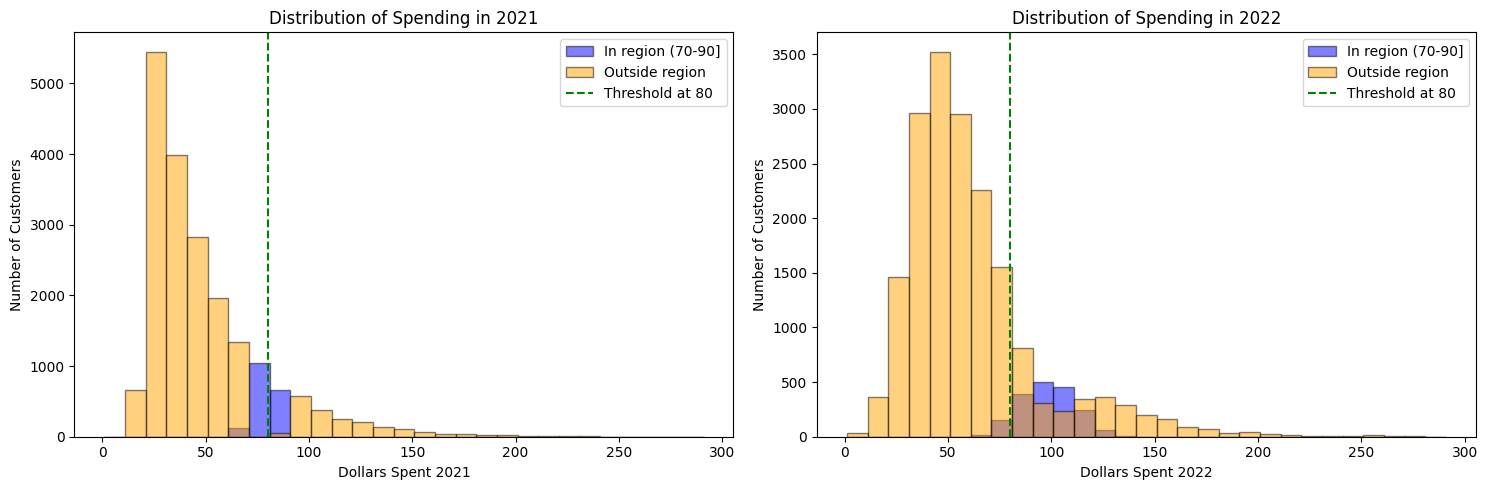

In [ ]:
explore_customers_around_threshold(df, 'Dollars Spent 2021', 'Dollars Spent 2022', threshold=80.0, range_size=10.0)

Customers in the threshold neighborhood:
       Dollars Spent 2021  Dollars Spent 2022
count         3918.000000         3918.000000
mean            75.769714           94.228188
std             11.196562           16.672760
min             60.002533           46.762512
25%             66.065594           81.718046
50%             73.883034           92.822670
75%             84.511503          106.607275
max             99.990959          147.747803

Customers outside the threshold neighborhood:
       Dollars Spent 2021  Dollars Spent 2022
count        16082.000000        16082.000000
mean            43.708000           57.666054
std             29.929033           33.317982
min             20.000851            4.977531
25%             26.712262           38.642661
50%             35.416538           50.123629
75%             47.609412           64.297558
max            312.478394          350.753540


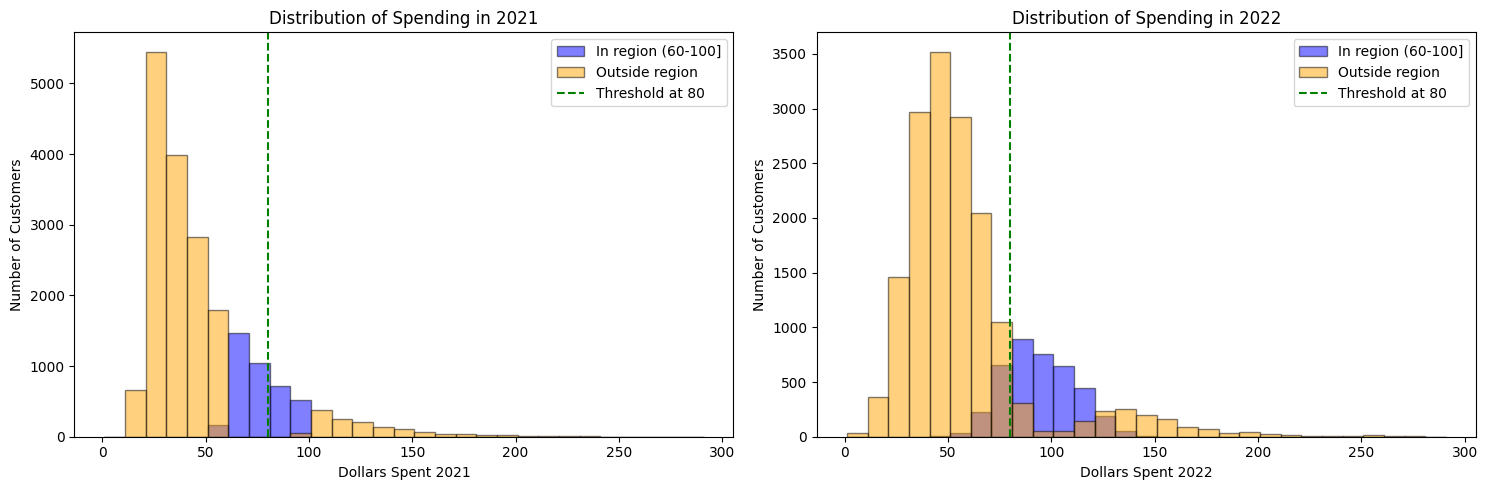

In [ ]:
explore_customers_around_threshold(df, 'Dollars Spent 2021', 'Dollars Spent 2022', threshold=80.0, range_size=20.0)

Customers in the threshold neighborhood:
       Dollars Spent 2021  Dollars Spent 2022
count         6353.000000         6353.000000
mean            70.835823           88.425728
std             15.834503           20.422705
min             50.005726           33.679604
25%             57.628391           73.017708
50%             67.113434           85.284927
75%             81.557602          103.020653
max            109.977272          155.651825

Customers outside the threshold neighborhood:
       Dollars Spent 2021  Dollars Spent 2022
count        13647.000000        13647.000000
mean            40.284157           53.843536
std             30.259945           33.504154
min             20.000851            4.977531
25%             25.530642           36.640280
50%             32.469490           46.778015
75%             41.455126           58.205860
max            312.478394          350.753540


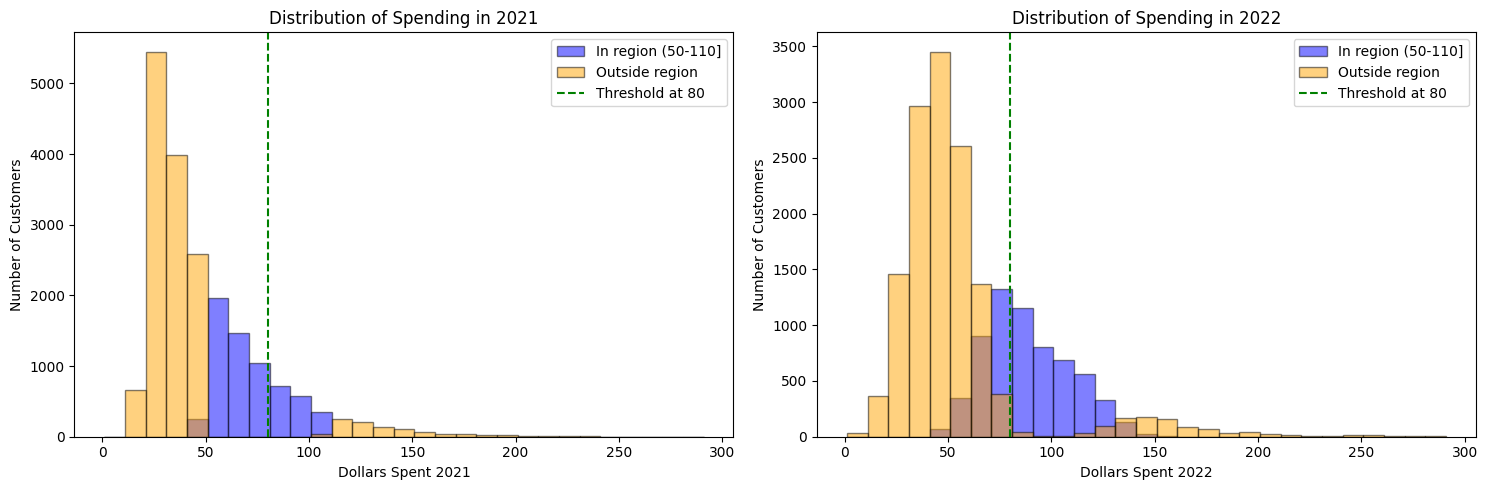

In [ ]:
explore_customers_around_threshold(df, 'Dollars Spent 2021', 'Dollars Spent 2022', threshold=80.0, range_size=30.0)

In [ ]:
df["Difference"] = df["Dollars Spent 2022"] - df["Dollars Spent 2021"]

lowerBound = 80
upperBound = 80



for i in range(8):
    lowerBound -= 10
    upperBound += 10

    df_nogift = df[(df["Dollars Spent 2021"] >= lowerBound) & (df["Dollars Spent 2021"] <= 80)]
    df_gift = df[(df["Dollars Spent 2021"] > 80) & (df["Dollars Spent 2021"] <= upperBound)]

    # Check if DataFrames are not empty
    if not df_gift.empty:
        m, b, r, p, std_err = stats.linregress(df_gift["Dollars Spent 2021"], df_gift["Difference"])
        m = round(m, 3)
        b = round(b, 3)

        print("Bandwidth:", (lowerBound, upperBound))

        print(f"Gift Region y = {m}x + {b}, r = {round(r, 3)}, p = {p:.3e}")

    if not df_nogift.empty:
        m, b, r, p, std_err = stats.linregress(df_nogift["Dollars Spent 2021"], df_nogift["Difference"])
        m = round(m, 3)
        b = round(b, 3)

        print(f"No Gift Region y = {m}x + {b}, r = {round(r, 3)}, p = {p:.3e}")

Bandwidth: (70, 90)
Gift Region y = -0.026x + 24.894, r = -0.008, p = 8.329e-01
No Gift Region y = 0.1x + 9.53, r = 0.03, p = 3.291e-01
Bandwidth: (60, 100)
Gift Region y = -0.128x + 33.345, r = -0.073, p = 7.480e-03
No Gift Region y = 0.053x + 13.005, r = 0.031, p = 1.148e-01
Bandwidth: (50, 110)
Gift Region y = -0.16x + 36.188, r = -0.132, p = 4.077e-08
No Gift Region y = 0.067x + 12.007, r = 0.057, p = 9.210e-05
Bandwidth: (40, 120)
Gift Region y = -0.145x + 34.776, r = -0.153, p = 7.023e-12
No Gift Region y = 0.085x + 10.843, r = 0.095, p = 1.528e-16
Bandwidth: (30, 130)
Gift Region y = -0.109x + 31.492, r = -0.144, p = 1.084e-11
No Gift Region y = 0.095x + 10.236, r = 0.128, p = 4.969e-44
Bandwidth: (20, 140)
Gift Region y = -0.095x + 30.199, r = -0.146, p = 1.225e-12
No Gift Region y = 0.102x + 9.844, r = 0.159, p = 8.923e-99
Bandwidth: (10, 150)
Gift Region y = -0.095x + 30.172, r = -0.165, p = 2.686e-16
No Gift Region y = 0.102x + 9.844, r = 0.159, p = 8.923e-99
Bandwidth: (0, 

## Initial Regression Model Specification

In [ ]:
df["Difference"] = df["Dollars Spent 2022"] - df["Dollars Spent 2021"]
df["Gift"] = ["Gift" if id > 80 else "No Gift" for id in df["Dollars Spent 2021"]]
df["floor_21"] = df["Dollars Spent 2021"].astype(int)
df["floor_22"] = df["Dollars Spent 2022"].astype(int)

df2 = df.groupby("floor_21").agg(mean_diff=("Difference", "mean"),
                                 count=("Difference", "count")).reset_index()
df2.head()

,floor_21,mean_diff,count
0,20,11.383988,663
1,21,11.890744,648
2,22,12.122943,613
3,23,12.243712,590
4,24,12.168145,600


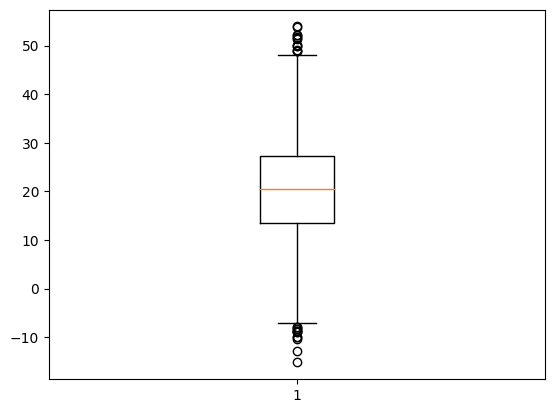

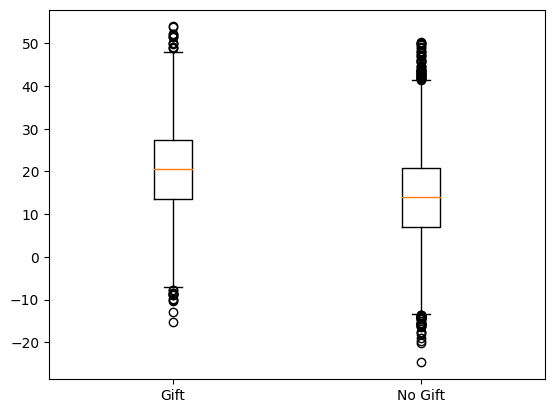

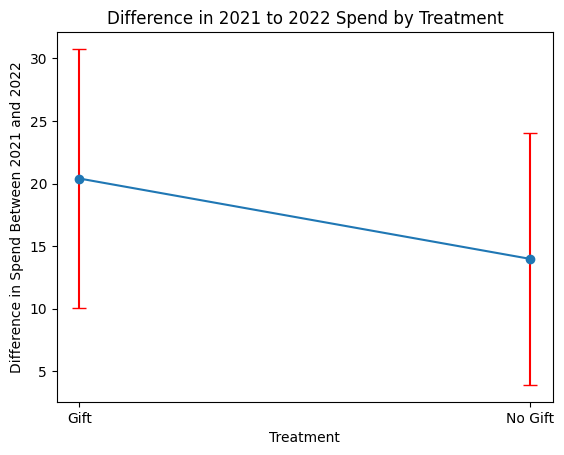

In [ ]:
df_nogift = df[df["Dollars Spent 2021"] <= 80]
df_gift = df[df["Dollars Spent 2021"] > 80]

A = plt.boxplot(df_gift["Difference"])
outliers = [item.get_ydata()[1] for item in A['whiskers']]
ol_clean = df_gift[df_gift["Difference"].between(outliers[0], outliers[1])]
plt.show()

plt.boxplot([df_gift["Difference"], df_nogift["Difference"]], labels=["Gift", "No Gift"])
plt.show()

means = df["Difference"].groupby(df["Gift"]).mean()
std = df["Difference"].groupby(df["Gift"]).std()

plt.errorbar(["Gift", "No Gift"], means, yerr=std, fmt="o-", ecolor="r", capsize=5)
plt.title("Difference in 2021 to 2022 Spend by Treatment")
plt.xlabel("Treatment")
plt.ylabel("Difference in Spend Between 2021 and 2022")
plt.show()

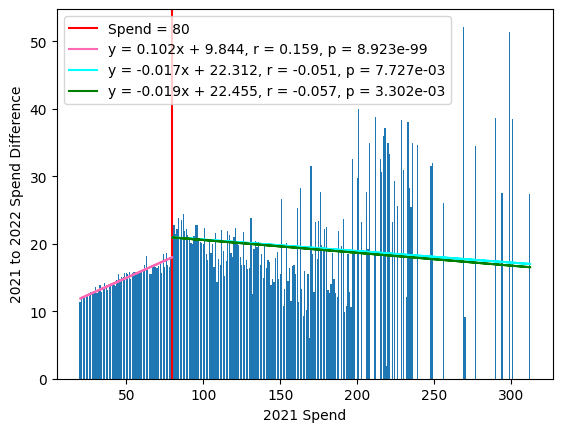

In [ ]:
plt.bar("floor_21", "mean_diff", data=df2)
plt.axvline(80, color="red", label="Spend = 80")

m, b, r, p, std_err = stats.linregress(df_nogift["Dollars Spent 2021"], df_nogift["Difference"])
m = round(m, 3)
b = round(b, 3)
yvals = list(m * df_nogift["Dollars Spent 2021"] + b)
plt.plot(df_nogift["Dollars Spent 2021"], yvals, color="hotpink",
         label=("y = "+str(m)+"x + "+str(b)+", r = "+str(round(r, 3))+", p = "+'{:0.3e}'.format(p)))

m, b, r, p, std_err = stats.linregress(df_gift["Dollars Spent 2021"], df_gift["Difference"])
m = round(m, 3)
b = round(b, 3)
yvals = list(m * df_gift["Dollars Spent 2021"] + b)
plt.plot(df_gift["Dollars Spent 2021"], yvals, color="cyan",
         label=("y = "+str(m)+"x + "+str(b)+", r = "+str(round(r, 3))+", p = "+'{:0.3e}'.format(p)))

m, b, r, p, std_err = stats.linregress(ol_clean["Dollars Spent 2021"], ol_clean["Difference"])
m = round(m, 3)
b = round(b, 3)
yvals = list(m * ol_clean["Dollars Spent 2021"] + b)
plt.plot(ol_clean["Dollars Spent 2021"], yvals, color="green",
         label=("y = "+str(m)+"x + "+str(b)+", r = "+str(round(r, 3))+", p = "+'{:0.3e}'.format(p)))

plt.xlabel("2021 Spend")
plt.ylabel("2021 to 2022 Spend Difference")
plt.legend()
plt.show()